#**Objective**

Build and compare Scikit-learn preprocessing pipelines and evaluate two classification models.

##**Part A**- Data Loading and Preprocessing with Scikit-learn

Task 1 - Load and Understand the Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv("hotel_bookings.csv")

In [ ]:
print("First 5 Rows")
print(df.head())

First 5 Rows
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Depo

In [ ]:
print("Shape")
print(df.shape)

Shape
(119390, 32)


In [ ]:
print("Information")
df.info()

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal

In [ ]:
print("Statistical Summary")
print(df.describe())

Statistical Summary
         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000   
75%                   3

In [ ]:
print("Target Class Distribution")
target_dist = df['is_canceled'].value_counts(normalize=True) * 100
print(f"Class Distribution (%):\n{target_dist}")

Target Class Distribution
Class Distribution (%):
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


Task 2 - Missing Values, Leakage, and Outliers

In [ ]:
# Missing value summary
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing_count, 'Percentage (%)': missing_percent})
print("Missing Value Analysis")
print(missing_df[missing_df['Count'] > 0])

Missing Value Analysis
           Count  Percentage (%)
children       4        0.003350
country      488        0.408744
agent      16340       13.686238
company   112593       94.306893


In [ ]:
# Drop high-missingness or non-informative columns
cols_to_drop = ['company', 'agent', 'reservation_status', 'reservation_status_date']
df_cleaned = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [ ]:
# Remove extreme outliers
initial_rows = len(df_cleaned)
df_cleaned = df_cleaned[(df_cleaned['adr'] >= 0) & (df_cleaned['adr'] < 1000)]
df_cleaned = df_cleaned[df_cleaned['adults'] <= 10]
rows_removed = initial_rows - len(df_cleaned)
print(f"Removed {rows_removed} extreme outlier rows.")

Removed 14 extreme outlier rows.


In [ ]:
# Separate Features (X) and Target (y)
y = df_cleaned['is_canceled']
X = df_cleaned.drop(columns=['is_canceled'])

In [ ]:
# Identify Numerical and Categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

Task 3 - Create Two Preprocessing Pipelines

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [ ]:
num_transformer_A = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

In [ ]:
num_transformer_B = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

In [ ]:
preprocessor_A = ColumnTransformer(transformers=[
    ('num', num_transformer_A, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [ ]:
preprocessor_B = ColumnTransformer(transformers=[
    ('num', num_transformer_B, num_cols),
    ('cat', cat_transformer, cat_cols)
])

##**Part B**- Model Training and Performance Evaluation

Task 4 & 5 - Train Two Classification Models and Evaluate the Four Results

In [ ]:
experiments = {
    "LogReg + Pipeline A (StandardScaler)": Pipeline([('prep', preprocessor_A), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    "LogReg + Pipeline B (MinMaxScaler)": Pipeline([('prep', preprocessor_B), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    "DecisionTree + Pipeline A (StandardScaler)": Pipeline([('prep', preprocessor_A), ('clf', DecisionTreeClassifier(random_state=42))]),
    "DecisionTree + Pipeline B (MinMaxScaler)": Pipeline([('prep', preprocessor_B), ('clf', DecisionTreeClassifier(random_state=42))]),
}

results = []
trained_pipelines = {}

for name, pipeline in experiments.items():
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    results.append({
        "Model Setup": name,
        "Train Acc": round(train_acc, 4),
        "Test Acc": round(test_acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

In [ ]:
# Final Evaluation Table
results_df = pd.DataFrame(results)
print("Performance Comparison Table")
print(results_df.to_string(index=False))

Performance Comparison Table
                               Model Setup  Train Acc  Test Acc  Precision  Recall  F1-Score
      LogReg + Pipeline A (StandardScaler)     0.8193    0.8168     0.8048  0.6673    0.7296
        LogReg + Pipeline B (MinMaxScaler)     0.8153    0.8138     0.8024  0.6596    0.7240
DecisionTree + Pipeline A (StandardScaler)     0.9961    0.8527     0.7995  0.8039    0.8017
  DecisionTree + Pipeline B (MinMaxScaler)     0.9961    0.8527     0.7998  0.8034    0.8016


<Figure size 600x500 with 0 Axes>

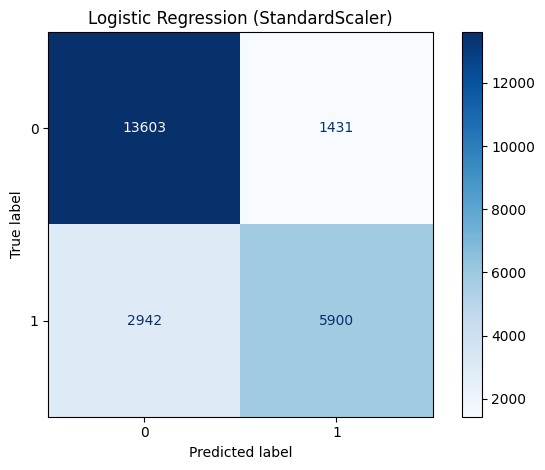

In [ ]:
# Best Logistic Regression Plot
plt.figure(figsize=(6, 5))
disp_lr = ConfusionMatrixDisplay.from_estimator(
    trained_pipelines["LogReg + Pipeline A (StandardScaler)"],
    X_test, y_test, cmap='Blues'
)
plt.title("Logistic Regression (StandardScaler)")
plt.tight_layout()
plt.savefig("cm_logistic_regression.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 600x500 with 0 Axes>

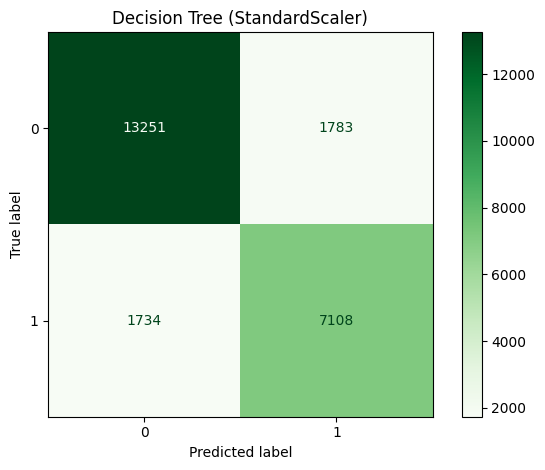

In [ ]:
# Best Decision Tree Plot
plt.figure(figsize=(6, 5))
disp_dt = ConfusionMatrixDisplay.from_estimator(
    trained_pipelines["DecisionTree + Pipeline A (StandardScaler)"],
    X_test, y_test, cmap='Greens'
)
plt.title("Decision Tree (StandardScaler)")
plt.tight_layout()
plt.savefig("cm_decision_tree.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df_cleaned.to_csv('hotel_bookings_cleaned.csv', index=False)

In [ ]:
results_df.to_csv("model_comparison_table.csv", index=False)